In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Kernel Restarts
import os
import transformers
import importlib.util

# --- Upgrade pip and ipywidgets early (essential for tqdm & widget-based outputs) --- #
os.system("pip install -q --upgrade pip")
os.system("pip install -q --upgrade ipywidgets")

# --- Helper function to check if a package is installed --- #
def is_installed(pkg_name):
    return importlib.util.find_spec(pkg_name) is not None

# --- Track if restart is needed --- #
restart_needed = False

# Ensure correct Transformers version
if transformers.__version__ != "4.54.1":
    print("⏬ Installing transformers==4.54.1...")
    os.system("pip install transformers==4.54.1 --quiet")
    restart_needed = True

# Remove keras if present
if is_installed("keras"):
    print("🧹 Removing keras (Keras 3.x breaks compatibility)...")
    os.system("pip uninstall -y keras --quiet")
    restart_needed = True

# Install tf-keras (backward-compatible shim)
if not is_installed("tf_keras"):
    print("✅ Installing tf-keras...")
    os.system("pip install tf-keras --quiet")
    restart_needed = True

# Install tensorflow-cpu (lightweight)
if not is_installed("tensorflow"):
    print("📦 Installing tensorflow-cpu...")
    os.system("pip install tensorflow-cpu --quiet")
    restart_needed = True

# Install HuggingFace ecosystem packages
for pkg in ["datasets", "accelerate", "evaluate"]:
    if not is_installed(pkg):
        print(f"📦 Installing {pkg}...")
        os.system(f"pip install {pkg} --quiet")
        restart_needed = True

# Restart the kernel to apply changes
if restart_needed:
    print("🔁 Restarting kernel to apply changes...")
    os.kill(os.getpid(), 9)
else:
    print("✅ All packages already properly installed and configured.")

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏬ Installing transformers==4.54.1...


🧹 Removing keras (Keras 3.x breaks compatibility)...


📦 Installing datasets...


📦 Installing evaluate...


In [2]:
# import os
# import transformers

# if transformers.__version__ != "4.54.1":
#     print("Restart required. Installing correct transformers version...")
#     os.system("pip install transformers==4.54.1 --quiet")
#     os.kill(os.getpid(), 9)  # force kernel restart

In [3]:
import transformers
print(transformers.__version__)

4.54.1


In [4]:
# from tqdm.auto import tqdm
# from time import sleep

# for i in tqdm(range(5)):
#     sleep(1)

We shall stick to using the CSV that contains extracted text from **Google's Cloud Vision OCR API**

# DeBERTa

In [5]:
import pandas as pd
import numpy as np
import torch
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
import copy
import matplotlib.pyplot as plt


/usr/local/lib/python3.10/site-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


## Loading the Model

In [6]:
model_name = "microsoft/deberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

E0000 00:00:1754390555.868694     255 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DebertaForSequenceClassification(
  (deberta): DebertaModel(
    (embeddings): DebertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=0)
      (LayerNorm): DebertaLayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaLayer(
          (attention): DebertaAttention(
            (self): DisentangledSelfAttention(
              (in_proj): Linear(in_features=768, out_features=2304, bias=False)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (pos_proj): Linear(in_features=768, out_features=768, bias=False)
              (pos_q_proj): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): DebertaLayerNorm()
              (dropout): Dropout(p=0

## Loading and Tokenizing the Dataset

In [7]:
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [8]:
root = "/kaggle/working/temp_data.csv"

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

In [9]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [11]:
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
import datasets

# First define the label names from your dataset
label_names = dataset['train'].unique('sentiment')
label_names.sort()

# Cast the sentiment column to ClassLabel
dataset = dataset.cast_column("sentiment", ClassLabel(names=label_names))

# Now you can stratify
split_dataset = dataset['train'].train_test_split(test_size=0.2, stratify_by_column="sentiment")

Casting the dataset:   0%|          | 0/2749 [00:00<?, ? examples/s]

In [12]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2199
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [13]:
type(split_dataset)

datasets.dataset_dict.DatasetDict

In [14]:
split = split_dataset['train'].train_test_split(test_size=0.1, stratify_by_column="sentiment")

final_dataset = datasets.dataset_dict.DatasetDict({
    'train': split['train'],
    'validation': split['test'],
    'test': split_dataset['test']
})

final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [19]:
# defining a function to tokenize the sentences
def tokenize_function(example):
    return tokenizer(
        example['OCR'],
        padding='max_length',           # pad all sequences to max_length
        truncation=True,                # truncate sequences longer than max_length
        max_length=128,                 # limit to 128 tokens
        return_attention_mask=True      # return attention mask
    )

# applying the tokenization function to the entire dataset in batches
tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1979 [00:00<?, ? examples/s]

Map:   0%|          | 0/220 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [20]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 550
    })
})

In [21]:
tokenized_dataset["train"]["attention_mask"]

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Preparing for Training

In [23]:
tokenized_dataset['train']['sentiment']

Column([0, 1, 2, 1, 0])

In [24]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

# -------------------------- TRAINING DATALOADER ---------------------------------------------------
# Convert to pandas DataFrame
df_train = tokenized_dataset['train'].to_pandas()

# Convert directly from lists to torch tensors (dtype: long)
train_inputs = torch.tensor(df_train['input_ids'].tolist(), dtype=torch.long)
train_attention = torch.tensor(df_train['attention_mask'].tolist(), dtype=torch.long)
train_labels = torch.tensor(df_train['sentiment'].tolist(), dtype=torch.long)  # use 'labels', not 'sentiment'

# Create TensorDataset and DataLoader
train_data = TensorDataset(train_inputs, train_attention, train_labels)
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)


# -------------------------- VALIDATION DATALOADER ---------------------------------------------------
df_val = tokenized_dataset['validation'].to_pandas()

val_inputs = torch.tensor(df_val['input_ids'].tolist(), dtype=torch.long)
val_attention = torch.tensor(df_val['attention_mask'].tolist(), dtype=torch.long)
val_labels = torch.tensor(df_val['sentiment'].tolist(), dtype=torch.long)

val_data = TensorDataset(val_inputs, val_attention, val_labels)
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=True)

In [25]:
tokenized_dataset['train']['sentiment']

Column([0, 1, 2, 1, 0])

## Training the Model

AdamW + Weight Decay + AMP + LR Scheduler

In [26]:
import torch
from torch.optim import AdamW
from transformers import get_scheduler
from torch.cuda.amp import autocast, GradScaler

# 1. Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Optimizer with weight decay grouping (recommended for T5)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=5e-5)

# 3. Learning rate scheduler
num_epochs = 3
num_training_steps = len(train_dataloader) * num_epochs

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 4. Mixed precision scaler (for AMP)
scaler = GradScaler()

# 5. Loss function is already handled inside T5 — just pass labels

/tmp/ipykernel_255/2959609429.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [27]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import copy

# === Settings ===
epochs = 10
patience = 3
min_delta = 1e-4
grad_clip_value = 1.0

# === Tracking ===
train_losses = []
val_losses = []
opt_train_loss = 0
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

scaler = torch.cuda.amp.GradScaler()  # For mixed precision

for epoch in range(epochs):
    # === Training ===
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training"):
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # Mixed Precision
            outputs = model(input_ids=b_input_ids,
                            attention_mask=b_attention_mask,
                            labels=b_labels)
            loss = outputs.loss

        total_train_loss += loss.item()

        scaler.scale(loss).backward()

        # Gradient Clipping (recommended for T5)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)

        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation"):
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=b_input_ids,
                                attention_mask=b_attention_mask,
                                labels=b_labels)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch + 1}:")
    print(f"  ➤ Avg Training Loss    = {avg_train_loss:.4f}")
    print(f"  ➤ Avg Validation Loss  = {avg_val_loss:.4f}")

    # === Early Stopping Logic ===
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        opt_train_loss = avg_train_loss
        epochs_no_improve = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement in validation loss ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping triggered after {epoch + 1} epochs.")
            break

# === Load the Best Model Back ===
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\n✅ Best model weights restored.")


/tmp/ipykernel_255/1649398397.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision
Epoch 1 - Training:   0%|          | 0/124 [00:00<?, ?it/s]/tmp/ipykernel_255/1649398397.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision
Epoch 1 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_255/1649398397.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1 - Validation: 100%|██████████| 14/14 [00:04<00:00,  3.43it/s]



Epoch 1:
  ➤ Avg Training Loss    = 0.5893
  ➤ Avg Validation Loss  = 0.3229
  ✅ Validation loss improved — saving best model.


Epoch 2 - Validation: 100%|██████████| 14/14 [00:04<00:00,  3.20it/s]



Epoch 2:
  ➤ Avg Training Loss    = 0.2505
  ➤ Avg Validation Loss  = 0.3399
  ⚠️ No improvement in validation loss (1/3)


Epoch 3 - Validation: 100%|██████████| 14/14 [00:04<00:00,  3.24it/s]



Epoch 3:
  ➤ Avg Training Loss    = 0.0957
  ➤ Avg Validation Loss  = 0.3400
  ⚠️ No improvement in validation loss (2/3)


Epoch 4 - Validation: 100%|██████████| 14/14 [00:04<00:00,  3.28it/s]



Epoch 4:
  ➤ Avg Training Loss    = 0.0641
  ➤ Avg Validation Loss  = 0.3456
  ⚠️ No improvement in validation loss (3/3)

⏹️ Early stopping triggered after 4 epochs.

✅ Best model weights restored.


In [28]:
if best_model_state:
    # model.load_state_dict(best_model_state)
    # print("\n✅ Best model weights restored.")
    # df_models["DeBERTa"] = {
    #     "TrainLoss" : opt_train_loss,
    #     "ValLoss" : best_val_loss,
    #     "Accuracy" : 0
    # }
    # Save the best model
    save_path = "DeBERTa__best_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Best model saved to {save_path}")

✅ Best model saved to DeBERTa__best_model.pt


In [36]:
df_models

,T5
TrainLoss,0.036847
ValLoss,0.037026
Accuracy,0.000000


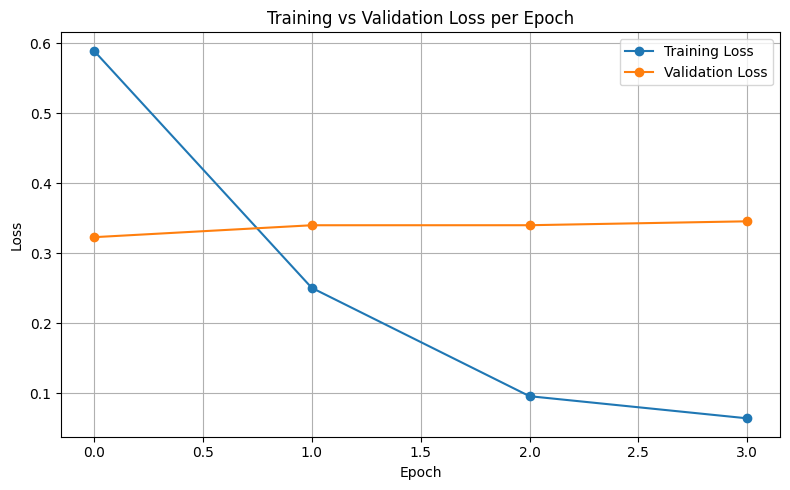

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("DeBERTa__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# epochs = 3
# for epoch in tqdm(range(epochs)):
#     model.train()
#     total_loss = 0
#     for batch in train_dataloader:
#         b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
#         # resetting gradients before backpropagation
#         model.zero_grad()
#         # performing a forward pass to calculate outputs
#         outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
#         # calculating the loss 
#         loss = outputs.loss
#         total_loss += loss.item()
#         # backpropagating the loss to compute gradients
#         loss.backward()
#         # updating model parameters using the computed gradients
#         optimizer.step()
#     avg_train_loss = total_loss / len(train_dataloader)
#     print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

## Making predictions

In [30]:
# Convert the tokenized test dataset to a DataFrame
df_test = tokenized_dataset['test'].to_pandas()

# Extract fields
X_test_inputs = np.array(df_test['input_ids'].tolist())
X_test_attention = np.array(df_test['attention_mask'].tolist())
y_test = np.array(df_test['sentiment'].tolist())  # Tokenized labels (IDs)

# Convert to PyTorch tensors
test_inputs = torch.tensor(X_test_inputs, dtype=torch.long)
test_attention = torch.tensor(X_test_attention, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [32]:
def get_predictions(model, dataloader):
    # setting the model to evaluation mode
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
            # forward pass to obtain model outputs
            outputs = model(b_input_ids, attention_mask=b_attention_mask)
            # extracting logits
            logits = outputs.logits
            # predicting the class with the highest score
            predicted_class = torch.argmax(logits, dim=1)
            # storing predictions and true labels for the current batch
            predictions.extend(predicted_class.cpu().numpy())
            true_labels.extend(b_labels.cpu().numpy())
    return predictions, true_labels

baseline_predictions, true_labels = get_predictions(model, test_dataloader)

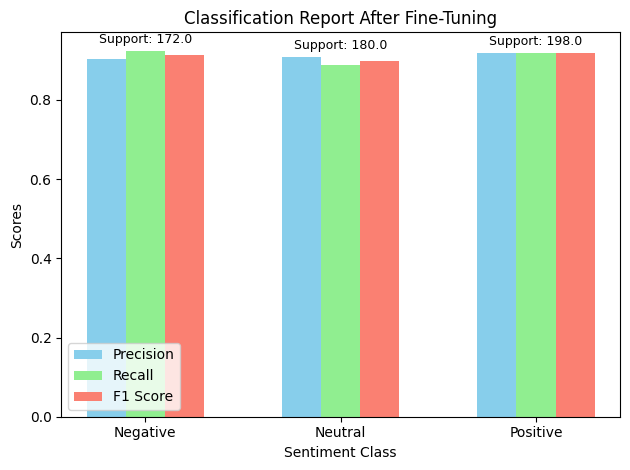

In [33]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [34]:
print(report['accuracy'])
# df_models["T5"] = report['accuracy']

0.9109090909090909


In [35]:
# df_models["T5"]
# report

In [36]:
import os
import pandas as pd

filepath = "/kaggle/working/tsa_model_expt_results.csv"

# Model results as a dict
df_model = {
    "Name": "DeBERTa",
    "Training Loss": opt_train_loss,
    "Validation Loss": best_val_loss,
    "Accuracy": report['accuracy']
}

# Convert to DataFrame
df_model = pd.DataFrame([df_model])  # Note the brackets to make it a list of dicts

# If file exists, append to it
if os.path.exists(filepath):
    results = pd.read_csv(filepath)
    results = results.loc[:, ~results.columns.str.contains('^Unnamed')]
    results = pd.concat([results, df_model], ignore_index=True)
else:
    results = df_model  # Start a new DataFrame

# Save the updated DataFrame back to CSV
# print(results)
results.to_csv(filepath, index=False)
results

,Name,Training Loss,Validation Loss,Accuracy
0,BART,0.148998,0.193558,0.909091
1,RoBERTa,0.081400,0.406700,0.941800
2,T5,0.038137,0.038477,0.887273
3,DeBERTa,0.589316,0.322900,0.910909


In [40]:
results.at[1,"Name"] = "DistilRoBERTa"
results.to_csv(filepath, index=False)
results

,Name,Training Loss,Validation Loss,Accuracy
0,BART,0.148998,0.193558,0.909091
1,DistilRoBERTa,0.081400,0.406700,0.941800
2,T5,0.038137,0.038477,0.887273
3,DeBERTa,0.589316,0.322900,0.910909


# DistilRoBERTa

Distilled version of RoBERTa

## Loading the Model

In [41]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# loading the tokenizer and model from HF transformers
tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')

# num_labels = 3 for Postive, Neutral, and Negative sentiment classes
model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base', num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Loading and Tokenizing the Dataset

In [42]:
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [43]:
root = "/kaggle/working/temp_data.csv"

In [44]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [45]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [46]:
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
import datasets

# First define the label names from your dataset
label_names = dataset['train'].unique('sentiment')
label_names.sort()

# Cast the sentiment column to ClassLabel
dataset = dataset.cast_column("sentiment", ClassLabel(names=label_names))

# Now you can stratify
split_dataset = dataset['train'].train_test_split(test_size=0.2, stratify_by_column="sentiment")

Casting the dataset:   0%|          | 0/2749 [00:00<?, ? examples/s]

In [47]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2199
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [48]:
type(split_dataset)

datasets.dataset_dict.DatasetDict

In [49]:
split = split_dataset['train'].train_test_split(test_size=0.1, stratify_by_column="sentiment")

final_dataset = datasets.dataset_dict.DatasetDict({
    'train': split['train'],
    'validation': split['test'],
    'test': split_dataset['test']
})

final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [50]:
# defining a function to tokenize the sentences
def tokenize_function(example):
    return tokenizer(
        example['OCR'],
        # padding sentences to the maximum length for consistent input size
        padding='max_length',
        # truncating sentences to fit within the model's expected input length
        truncation=True,
        # returning attention masks to let the model know which tokens are padding
        return_attention_mask=True
    )

# applying the tokenization function to the entire dataset in batches
tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1979 [00:00<?, ? examples/s]

Map:   0%|          | 0/220 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [51]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 550
    })
})

In [52]:
tokenized_dataset["train"]["attention_mask"]

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Preparing for Training

In [53]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

# -------------------------- TRAINING DATALOADER ---------------------------------------------------
# converting the tokenized train dataset to a pandas DataFrame
df_train = tokenized_dataset['train'].to_pandas()

# extracting input_ids, attention mask, and label from the DataFrame and converting to numpy array
X_train_inputs = np.array(list(df_train['input_ids']))
X_train_attention = np.array(list(df_train['attention_mask']))
y_train = df_train['sentiment']

# converting to tensors
train_inputs = torch.tensor(X_train_inputs)
train_attention = torch.tensor(X_train_attention)
train_labels = torch.tensor(y_train.values)

# creating a TensorDataset from inputs, attention masks, and labels
train_data = TensorDataset(train_inputs, train_attention, train_labels)

# creating a DataLoader for batching the train data
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)


# -------------------------- VALIDATION DATALOADER ---------------------------------------------------
# converting the tokenized train dataset to a pandas DataFrame
df_val = tokenized_dataset['validation'].to_pandas()

# extracting input_ids, attention mask, and label from the DataFrame and converting to numpy array
X_val_inputs = np.array(list(df_val['input_ids']))
X_val_attention = np.array(list(df_val['attention_mask']))
y_val = df_val['sentiment']

# converting to tensors
val_inputs = torch.tensor(X_val_inputs)
val_attention = torch.tensor(X_val_attention)
val_labels = torch.tensor(y_val.values)

# creating a TensorDataset from inputs, attention masks, and labels
val_data = TensorDataset(val_inputs, val_attention, val_labels)

# creating a DataLoader for batching the train data
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=True) # Step 4: Evaluating the Model

In [54]:
tokenized_dataset['train']['sentiment']

Column([0, 0, 2, 2, 1])

## Training the Model

AdamW + Weight Decay + AMP + LR Scheduler

In [55]:
import torch
from torch.optim import AdamW
from transformers import get_scheduler
from torch.cuda.amp import autocast, GradScaler

# 1. Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Optimizer with weight decay grouping (recommended for T5)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=5e-5)

# 3. Learning rate scheduler
num_epochs = 3
num_training_steps = len(train_dataloader) * num_epochs

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 4. Mixed precision scaler (for AMP)
scaler = GradScaler()

# 5. Loss function is already handled inside T5 — just pass labels

/tmp/ipykernel_255/2959609429.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [56]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import copy

# === Settings ===
epochs = 10
patience = 3
min_delta = 1e-4
grad_clip_value = 1.0

# === Tracking ===
train_losses = []
val_losses = []
opt_train_loss = 0
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

scaler = torch.cuda.amp.GradScaler()  # For mixed precision

for epoch in range(epochs):
    # === Training ===
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training"):
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # Mixed Precision
            outputs = model(input_ids=b_input_ids,
                            attention_mask=b_attention_mask,
                            labels=b_labels)
            loss = outputs.loss

        total_train_loss += loss.item()

        scaler.scale(loss).backward()

        # Gradient Clipping (recommended for T5)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)

        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation"):
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=b_input_ids,
                                attention_mask=b_attention_mask,
                                labels=b_labels)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch + 1}:")
    print(f"  ➤ Avg Training Loss    = {avg_train_loss:.4f}")
    print(f"  ➤ Avg Validation Loss  = {avg_val_loss:.4f}")

    # === Early Stopping Logic ===
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        opt_train_loss = avg_train_loss
        epochs_no_improve = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement in validation loss ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping triggered after {epoch + 1} epochs.")
            break

# === Load the Best Model Back ===
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\n✅ Best model weights restored.")


/tmp/ipykernel_255/1649398397.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision
Epoch 1 - Training:   0%|          | 0/124 [00:00<?, ?it/s]/tmp/ipykernel_255/1649398397.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision
/usr/local/lib/python3.10/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Epoch 1 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_255/1649398397.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoc


Epoch 1:
  ➤ Avg Training Loss    = 0.5180
  ➤ Avg Validation Loss  = 0.4681
  ✅ Validation loss improved — saving best model.


Epoch 2 - Validation: 100%|██████████| 14/14 [00:06<00:00,  2.31it/s]



Epoch 2:
  ➤ Avg Training Loss    = 0.2367
  ➤ Avg Validation Loss  = 0.2497
  ✅ Validation loss improved — saving best model.


Epoch 3 - Validation: 100%|██████████| 14/14 [00:05<00:00,  2.72it/s]



Epoch 3:
  ➤ Avg Training Loss    = 0.1342
  ➤ Avg Validation Loss  = 0.2576
  ⚠️ No improvement in validation loss (1/3)


Epoch 4 - Validation: 100%|██████████| 14/14 [00:06<00:00,  2.29it/s]



Epoch 4:
  ➤ Avg Training Loss    = 0.1041
  ➤ Avg Validation Loss  = 0.2712
  ⚠️ No improvement in validation loss (2/3)


Epoch 5 - Validation: 100%|██████████| 14/14 [00:05<00:00,  2.47it/s]



Epoch 5:
  ➤ Avg Training Loss    = 0.1027
  ➤ Avg Validation Loss  = 0.2595
  ⚠️ No improvement in validation loss (3/3)

⏹️ Early stopping triggered after 5 epochs.

✅ Best model weights restored.


In [57]:
if best_model_state:
    # model.load_state_dict(best_model_state)
    # print("\n✅ Best model weights restored.")
    
    # Save the best model
    save_path = "distilRoBERTa__best_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Best model saved to {save_path}")

✅ Best model saved to distilRoBERTa__best_model.pt


In [36]:
# df_models

,T5
TrainLoss,0.036847
ValLoss,0.037026
Accuracy,0.000000


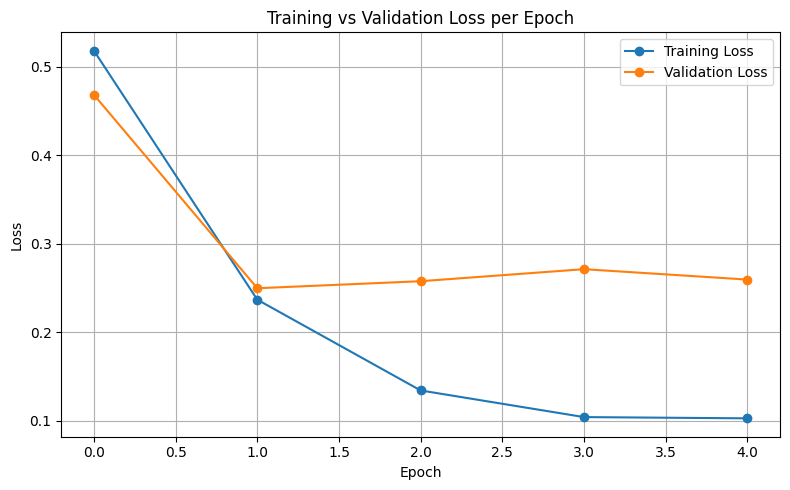

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("DistilRoBERTa__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [59]:
# epochs = 3
# for epoch in tqdm(range(epochs)):
#     model.train()
#     total_loss = 0
#     for batch in train_dataloader:
#         b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
#         # resetting gradients before backpropagation
#         model.zero_grad()
#         # performing a forward pass to calculate outputs
#         outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
#         # calculating the loss 
#         loss = outputs.loss
#         total_loss += loss.item()
#         # backpropagating the loss to compute gradients
#         loss.backward()
#         # updating model parameters using the computed gradients
#         optimizer.step()
#     avg_train_loss = total_loss / len(train_dataloader)
#     print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

## Making predictions

In [60]:
# Convert the tokenized test dataset to a DataFrame
df_test = tokenized_dataset['test'].to_pandas()

# Extract fields
X_test_inputs = np.array(df_test['input_ids'].tolist())
X_test_attention = np.array(df_test['attention_mask'].tolist())
y_test = np.array(df_test['sentiment'].tolist())  # Tokenized labels (IDs)

# Convert to PyTorch tensors
test_inputs = torch.tensor(X_test_inputs, dtype=torch.long)
test_attention = torch.tensor(X_test_attention, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [61]:
def get_predictions(model, dataloader):
    # setting the model to evaluation mode
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
            # forward pass to obtain model outputs
            outputs = model(b_input_ids, attention_mask=b_attention_mask)
            # extracting logits
            logits = outputs.logits
            # predicting the class with the highest score
            predicted_class = torch.argmax(logits, dim=1)
            # storing predictions and true labels for the current batch
            predictions.extend(predicted_class.cpu().numpy())
            true_labels.extend(b_labels.cpu().numpy())
    return predictions, true_labels

baseline_predictions, true_labels = get_predictions(model, test_dataloader)

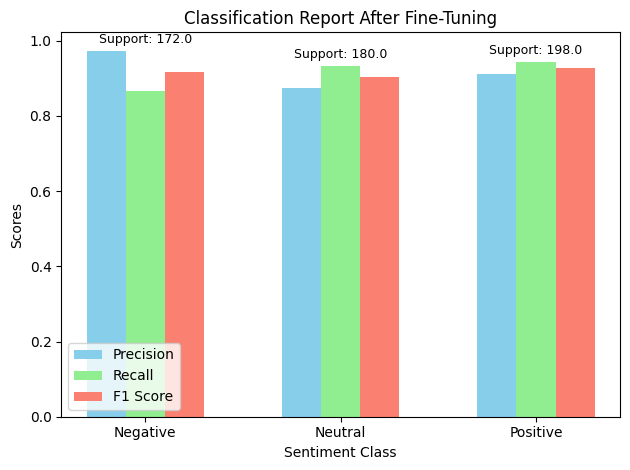

In [62]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [64]:
print(report['accuracy'])
# df_models["T5"] = report['accuracy']

0.9163636363636364


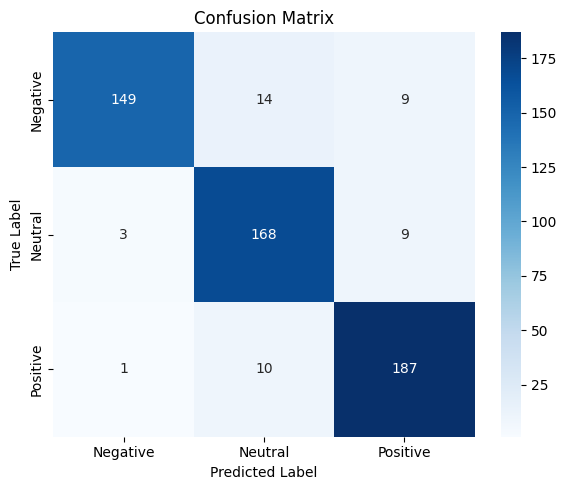

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define class labels
class_names = ['Negative', 'Neutral', 'Positive']

# Generate confusion matrix
cm = confusion_matrix(true_labels, baseline_predictions)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


In [66]:
filepath = "/kaggle/working/tsa_model_expt_results.csv"
results = pd.read_csv(filepath)
results.at[1, "Training Loss"] = avg_train_loss
results.at[1, "Validation Loss"] = avg_val_loss
results.at[1, "Accuracy"] = report['accuracy']

In [67]:
results

,Name,Training Loss,Validation Loss,Accuracy
0,BART,0.148998,0.193558,0.909091
1,DistilRoBERTa,0.102694,0.259452,0.916364
2,T5,0.038137,0.038477,0.887273
3,DeBERTa,0.589316,0.322900,0.910909


In [68]:
results.to_csv("tsa_model_expt_results.csv", index=False)

In [71]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import json

# Replace these with your actual predictions and true labels
# preds = predicted_labels  # e.g., ['positive', 'neutral', 'negative', ...]
# true_labels = actual_labels  # e.g., ['positive', 'neutral', 'negative', ...]

# Optional: define label order
# label_order = ["negative", "neutral", "positive"]

# Compute metrics
# cm = confusion_matrix(true_labels, baseline_predictions, labels=label_order)
# cr = classification_report(true_labels, preds, labels=label_order, output_dict=True)

# Package results into a dictionary
results = {
    "model_name": "DistilRoBERTa",
    "confusion_matrix": cm.tolist(),  # convert to list for saving
    "classification_report": report
}

# Save to JSON file
with open("tsa_evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

# BART

## Loading the Model

In [47]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AutoModelForSequenceClassification

# Load tokenizer and model (TensorFlow version) from HuggingFace
tokenizer = AutoTokenizer.from_pretrained('facebook/bart-base')

# num_labels = 3 for Positive, Neutral, and Negative sentiment classes
# model = TFAutoModelForSequenceClassification.from_pretrained('facebook/bart-base', num_labels=3) # TensorFlow type
model = AutoModelForSequenceClassification.from_pretrained('facebook/bart-base', num_labels=3) # PyTorch type

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Loading and Tokenizing the Dataset

In [48]:
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [49]:
root = "/kaggle/working/temp_data.csv"

In [50]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [51]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [52]:
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
import datasets

# First define the label names from your dataset
label_names = dataset['train'].unique('sentiment')
label_names.sort()

# Cast the sentiment column to ClassLabel
dataset = dataset.cast_column("sentiment", ClassLabel(names=label_names))

# Now you can stratify
split_dataset = dataset['train'].train_test_split(test_size=0.2, stratify_by_column="sentiment")

Casting the dataset:   0%|          | 0/2749 [00:00<?, ? examples/s]

In [53]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2199
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [54]:
type(split_dataset)

datasets.dataset_dict.DatasetDict

In [55]:
split = split_dataset['train'].train_test_split(test_size=0.1, stratify_by_column="sentiment")

final_dataset = datasets.dataset_dict.DatasetDict({
    'train': split['train'],
    'validation': split['test'],
    'test': split_dataset['test']
})

final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [56]:
# defining a function to tokenize the sentences
def tokenize_function(example):
    return tokenizer(
        example['OCR'],
        # padding sentences to the maximum length for consistent input size
        padding='max_length',
        # truncating sentences to fit within the model's expected input length
        truncation=True,
        # returning attention masks to let the model know which tokens are padding
        return_attention_mask=True,
        max_length = 128 # (default if set to 1024)
    )

# applying the tokenization function to the entire dataset in batches
tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1979 [00:00<?, ? examples/s]

Map:   0%|          | 0/220 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [57]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask'],
        num_rows: 550
    })
})

In [58]:
tokenized_dataset["train"]["attention_mask"]

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Preparing for Training

In [59]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

# -------------------------- TRAINING DATALOADER ---------------------------------------------------
# converting the tokenized train dataset to a pandas DataFrame
df_train = tokenized_dataset['train'].to_pandas()

# extracting input_ids, attention mask, and label from the DataFrame and converting to numpy array
X_train_inputs = np.array(list(df_train['input_ids']))
X_train_attention = np.array(list(df_train['attention_mask']))
y_train = df_train['sentiment']

# converting to tensors
train_inputs = torch.tensor(X_train_inputs)
train_attention = torch.tensor(X_train_attention)
train_labels = torch.tensor(y_train.values)

# creating a TensorDataset from inputs, attention masks, and labels
train_data = TensorDataset(train_inputs, train_attention, train_labels)

# creating a DataLoader for batching the train data
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)


# -------------------------- TRAINING DATALOADER ---------------------------------------------------
# converting the tokenized train dataset to a pandas DataFrame
df_val = tokenized_dataset['validation'].to_pandas()

# extracting input_ids, attention mask, and label from the DataFrame and converting to numpy array
X_val_inputs = np.array(list(df_val['input_ids']))
X_val_attention = np.array(list(df_val['attention_mask']))
y_val = df_val['sentiment']

# converting to tensors
val_inputs = torch.tensor(X_val_inputs)
val_attention = torch.tensor(X_val_attention)
val_labels = torch.tensor(y_val.values)

# creating a TensorDataset from inputs, attention masks, and labels
val_data = TensorDataset(val_inputs, val_attention, val_labels)

# creating a DataLoader for batching the train data
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=True) # Step 4: Evaluating the Model

In [60]:
list(df_train['input_ids'])[0]

array([    0, 13354, 50118,   104, 23617,  1862, 50118, 45380,   116,
       50118, 13796,  2889, 50118,   565,  7111,  2547,     2,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1]

In [61]:
df_train

,OCR,sentiment,input_ids,attention_mask
0,THE\nSINKING\nSTATE?\nINDIA\nTODAY,0,"[0, 13354, 50118, 104, 23617, 1862, 50118, 453...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,KERALA FLOODS: SEVERE CALAMITY,0,"[0, 530, 39243, 250, 8854, 26462, 104, 35, 632...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"Without rain\nnothing grows,\nLearn to embrace...",2,"[0, 20867, 1895, 50118, 23702, 11461, 6, 50118...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,nh404@Desktop: $ python3.10\nPython 3.10.4 (ma...,1,"[0, 282, 298, 32957, 1039, 45469, 35, 68, 3982...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,sky NEWS Special Report\nSuicide bomb attack\n...,0,"[0, 18708, 7857, 3672, 2872, 50118, 20689, 157...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ..."
...,...,...,...,...
1974,"Go out in nature,\nground yourself\nand relax....",2,"[0, 11478, 66, 11, 2574, 6, 50118, 13981, 2512...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1975,PRAY FOR KERALA,0,"[0, 510, 37327, 5089, 229, 39243, 250, 2, 1, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ..."
1976,CL\nMagic\nREPPER\n10 SHTF\nAPARTMENT\nPREPS,1,"[0, 7454, 50118, 35877, 50118, 4629, 5756, 207...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1977,Happy Holi 2021 wishes,2,"[0, 21136, 6217, 118, 8835, 8605, 2, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Training the Model

In [62]:
# from transformers import AdamW
from torch.optim import AdamW

# set up the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# put the model on device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BartForSequenceClassification(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_

In [63]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import copy

# === Settings ===
epochs = 10
patience = 3  # Number of epochs to wait after no improvement
min_delta = 1e-4  # Minimum change to qualify as improvement

# === Tracking ===
train_losses = []
opt_train_loss = 0
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

for epoch in range(epochs):
    # === Training ===
    model.train()
    total_train_loss = 0
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training"):
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
        model.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation"):
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
            outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
            val_loss = outputs.loss
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch + 1}:")
    print(f"  ➤ Avg Training Loss    = {avg_train_loss:.4f}")
    print(f"  ➤ Avg Validation Loss  = {avg_val_loss:.4f}")

    # === Early Stopping Logic ===
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        opt_train_loss = avg_train_loss
        epochs_no_improve = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement in validation loss ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping triggered after {epoch + 1} epochs.")
            break

# === Load the Best Model Back ===
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\n✅ Best model weights restored.")

Epoch 1 - Validation: 100%|██████████| 14/14 [00:04<00:00,  3.46it/s]



Epoch 1:
  ➤ Avg Training Loss    = 0.5808
  ➤ Avg Validation Loss  = 0.3767
  ✅ Validation loss improved — saving best model.


Epoch 2 - Validation: 100%|██████████| 14/14 [00:03<00:00,  3.75it/s]



Epoch 2:
  ➤ Avg Training Loss    = 0.2945
  ➤ Avg Validation Loss  = 0.2247
  ✅ Validation loss improved — saving best model.


Epoch 3 - Validation: 100%|██████████| 14/14 [00:03<00:00,  4.26it/s]


...


Epoch 4:
  ➤ Avg Training Loss    = 0.0956
  ➤ Avg Validation Loss  = 0.2233
  ⚠️ No improvement in validation loss (1/3)


Epoch 5 - Validation: 100%|██████████| 14/14 [00:03<00:00,  3.51it/s]



Epoch 5:
  ➤ Avg Training Loss    = 0.0749
  ➤ Avg Validation Loss  = 0.3017
  ⚠️ No improvement in validation loss (2/3)


Epoch 6 - Validation: 100%|██████████| 14/14 [00:03<00:00,  4.31it/s]



Epoch 6:
  ➤ Avg Training Loss    = 0.0682
  ➤ Avg Validation Loss  = 0.2673
  ⚠️ No improvement in validation loss (3/3)

⏹️ Early stopping triggered after 6 epochs.

✅ Best model weights restored.


In [72]:
if best_model_state:
    # model.load_state_dict(best_model_state)
    # print("\n✅ Best model weights restored.")
    df_models["BART"] = {
        "TrainLoss" : opt_train_loss,
        "ValLoss" : best_val_loss,
        "Accuracy" : 0
    }
    # Save the best model
    save_path = "bart__best_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Best model saved to {save_path}")

✅ Best model saved to bart__best_model.pt


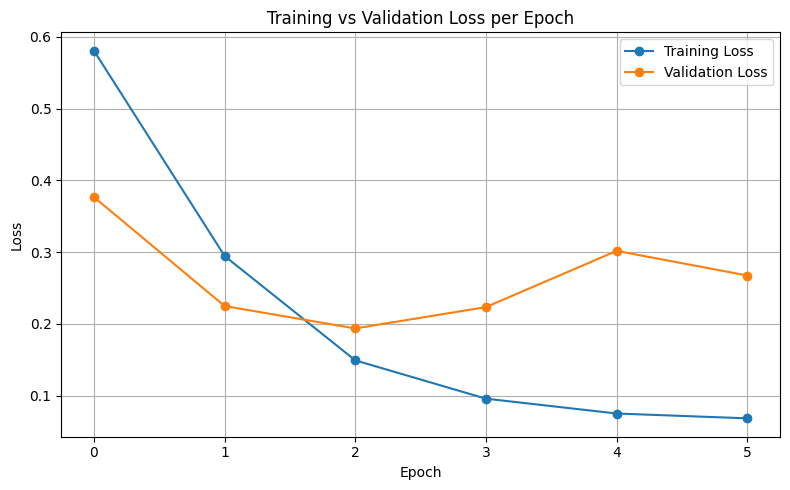

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("BART__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# epochs = 3
# for epoch in tqdm(range(epochs)):
#     model.train()
#     total_loss = 0
#     for batch in train_dataloader:
#         b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
#         # resetting gradients before backpropagation
#         model.zero_grad()
#         # performing a forward pass to calculate outputs
#         outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
#         # calculating the loss 
#         loss = outputs.loss
#         total_loss += loss.item()
#         # backpropagating the loss to compute gradients
#         loss.backward()
#         # updating model parameters using the computed gradients
#         optimizer.step()
#     avg_train_loss = total_loss / len(train_dataloader)
#     print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

## Making predictions

In [66]:
# converting the tokenized test dataset to a pandas DataFrame
df_test = tokenized_dataset['test'].to_pandas()

X_test_inputs = np.array(list(df_test['input_ids']))
X_test_attention = np.array(list(df_test['attention_mask']))
y_test = df_test['sentiment']

# converting input_ids to tensor
test_inputs = torch.tensor(X_test_inputs)
test_attention = torch.tensor(X_test_attention)
test_labels = torch.tensor(y_test.values)

# creating a TensorDataset & DataLoader from inputs, attention masks, and labels
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [67]:
def get_predictions(model, dataloader):
    # setting the model to evaluation mode
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
            # forward pass to obtain model outputs
            outputs = model(b_input_ids, attention_mask=b_attention_mask)
            # extracting logits
            logits = outputs.logits
            # predicting the class with the highest score
            predicted_class = torch.argmax(logits, dim=1)
            # storing predictions and true labels for the current batch
            predictions.extend(predicted_class.cpu().numpy())
            true_labels.extend(b_labels.cpu().numpy())
    return predictions, true_labels

baseline_predictions, true_labels = get_predictions(model, test_dataloader)

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


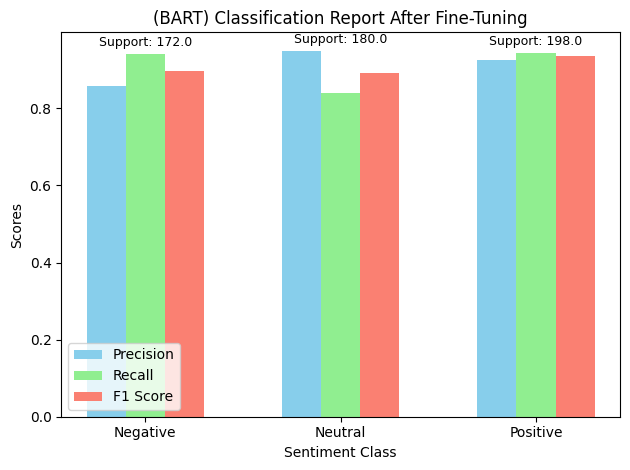

In [68]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('(BART) Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [73]:
print(report['accuracy'])

0.9090909090909091


In [75]:
df_models["BART"]["Accuracy"] = report['accuracy']
report

{'Negative': {'precision': 0.8571428571428571,
  'recall': 0.9418604651162791,
  'f1-score': 0.8975069252077562,
  'support': 172.0},
 'Neutral': {'precision': 0.949685534591195,
  'recall': 0.8388888888888889,
  'f1-score': 0.8908554572271387,
  'support': 180.0},
 'Positive': {'precision': 0.9257425742574258,
  'recall': 0.9444444444444444,
  'f1-score': 0.935,
  'support': 198.0},
 'accuracy': 0.9090909090909091,
 'macro avg': {'precision': 0.9108569886638259,
  'recall': 0.9083979328165374,
  'f1-score': 0.9077874608116318,
  'support': 550.0},
 'weighted avg': {'precision': 0.9121254497417397,
  'recall': 0.9090909090909091,
  'f1-score': 0.90882758806658,
  'support': 550.0}}

In [84]:
# df_models = pd.DataFrame(df_models)
df_models.to_csv("tsa_model_expt_results.csv", index=False)

In [81]:
df_models["BART"]["Accuracy"]

0.9090909090909091

In [85]:
df_models

,BART
TrainLoss,0.148998
ValLoss,0.193558
Accuracy,0.909091


# T5

## Loading the Model

In [1]:
from transformers import AutoTokenizer, T5ForConditionalGeneration

# Load tokenizer and model (T5, PyTorch version)
tokenizer = AutoTokenizer.from_pretrained('t5-base')
model = T5ForConditionalGeneration.from_pretrained('t5-base')

/usr/local/lib/python3.10/site-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
E0000 00:00:1754374286.348844     258 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:230


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

## Loading and Tokenizing the Dataset

In [3]:
import pandas as pd
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [4]:
root = "/kaggle/working/temp_data.csv"

In [5]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [7]:
type(dataset['train'])

datasets.arrow_dataset.Dataset

In [8]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import pandas as pd

# Convert Hugging Face dataset to pandas DataFrame
df = dataset['train'].to_pandas()

# First split: 80% train_val, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

# Second split: from train_val_df, get 87.5% train and 12.5% val
# This results in 70/10 train/val overall
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,  # 0.125 * 0.8 = 0.10
    stratify=train_val_df['sentiment'],
    random_state=42
)

# Convert back to Hugging Face Arrow Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

# Wrap in DatasetDict
final_dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

In [9]:
final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [10]:
type(final_dataset)

datasets.dataset_dict.DatasetDict

In [11]:
print(final_dataset['validation'].to_pandas())

                                                   OCR sentiment
0                                 THIS BIKE\nPROVES IT   neutral
1    Never give up.\nGreat things\ntake time.\nBe p...  positive
2    INDIA\nTODAY\nTHANE BUILDING\nCOLLAPSE\n10 DEA...  negative
3    Don't lose hope, you never know\nwhat tomorrow...  positive
4                                        KERALA FLOODS  negative
..                                                 ...       ...
270  WALL COLLAPSED,\n9 PEOPLE DIED IN LUCKNOW\nOne...  negative
271  ALMOST\n10%\n•\nOF THE\nPEOPLE\nIN FRANCE AGED...   neutral
272                     DEATH TOLL CROSSES 1 LAKH MARK  negative
273  when you write 10\nlines of code without\nsear...  positive
274  Shayarisove\nSmile, smile at your mind as\noft...  positive

[275 rows x 2 columns]


In [12]:
# # defining a function to tokenize the sentences
# def tokenize_function(example):
#     return tokenizer(
#         example['OCR'],
#         # padding sentences to the maximum length for consistent input size
#         padding='max_length',
#         # truncating sentences to fit within the model's expected input length
#         truncation=True,
#         # returning attention masks to let the model know which tokens are padding
#         return_attention_mask=True,
#         max_length = 128 # (default if set to 1024)
#     )

# # applying the tokenization function to the entire dataset in batches
# tokenized_dataset = final_dataset.map(tokenize_function, batched=True)


def tokenize_function(example):
    # Format input and target strings
    inputs = ["sentiment analysis: " + ocr for ocr in example['OCR']]
    targets = example['sentiment']  # already text: "positive", etc.

    # Tokenize inputs and targets
    model_inputs = tokenizer(
        inputs,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_attention_mask=True
    )

    # Tokenize targets as labels
    labels = tokenizer(
        targets,
        padding="max_length",
        truncation=True,
        max_length=10  # sentiment words are short
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Map:   0%|          | 0/275 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [13]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 550
    })
})

In [14]:
tokenized_dataset["train"]["attention_mask"]

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Preparing for Training

In [15]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

# -------------------------- TRAINING DATALOADER ---------------------------------------------------


# Convert tokenized dataset to pandas
df_train = tokenized_dataset['train'].to_pandas()

# Extract inputs
X_train_inputs = np.array(df_train['input_ids'].tolist())
X_train_attention = np.array(df_train['attention_mask'].tolist())
y_train = np.array(df_train['labels'].tolist())  # already tokenized label IDs

# Convert to tensors
train_inputs = torch.tensor(X_train_inputs, dtype=torch.long)
train_attention = torch.tensor(X_train_attention, dtype=torch.long)
train_labels = torch.tensor(y_train, dtype=torch.long)

# Create TensorDataset
train_data = TensorDataset(train_inputs, train_attention, train_labels)

# DataLoader
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)



# -------------------------- TRAINING DATALOADER ---------------------------------------------------
df_val = tokenized_dataset['validation'].to_pandas()
X_val_inputs = np.array(df_val['input_ids'].tolist())
X_val_attention = np.array(df_val['attention_mask'].tolist())
y_val = np.array(df_val['labels'].tolist())

val_inputs = torch.tensor(X_val_inputs, dtype=torch.long)
val_attention = torch.tensor(X_val_attention, dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.long)

val_data = TensorDataset(val_inputs, val_attention, val_labels)
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=False)

In [16]:
list(df_train['input_ids'])[0]

array([ 6493,  1693,    10,     3,  8727,  5080,   439,   283,   476,
         382,  6299, 20151,   476,     1,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0]

In [17]:
df_train

,OCR,sentiment,input_ids,attention_mask,labels
0,GREEK\nMYTHOLOGY,neutral,"[6493, 1693, 10, 3, 8727, 5080, 439, 283, 476,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...","[7163, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1,The Call-Chronicle-Examiner\nEARTHQUAKE AND FI...,negative,"[6493, 1693, 10, 37, 2571, 18, 3541, 18074, 24...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
2,"""May the festival of colours\nbrings the brigh...",positive,"[6493, 1693, 10, 96, 15881, 8, 3994, 13, 6548,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
3,for\nOXFORD\nSTUNNED BY\nTEEN'S DEATH,negative,"[6493, 1693, 10, 21, 411, 4, 371, 18400, 5097,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"August 23rd, 2011\nVirginia earthquake",negative,"[6493, 1693, 10, 1660, 1902, 52, 26, 6, 2722, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
1919,"MIND JOURNAL\n""What is Pain?""\nThe moment when...",negative,"[6493, 1693, 10, 283, 13885, 446, 9131, 567, 4...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1920,Veritasium\nVeritasium\nVeri\nVaritasi\nritasi...,neutral,"[6493, 1693, 10, 781, 155, 9, 7, 2552, 781, 15...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[7163, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1921,You only\nfail when\n@Meltblogs\nyou stop\ntry...,positive,"[6493, 1693, 10, 148, 163, 5124, 116, 3320, 32...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1922,You must teach\nyour heart to accept\nwhat can...,positive,"[6493, 1693, 10, 148, 398, 3884, 39, 842, 12, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"


In [19]:
# true_text_labels = df_test['sentiment'].tolist()  # For later decoding/evaluation

## Training the Model

In [20]:
import torch
from torch.optim import AdamW
from transformers import get_scheduler
from torch.cuda.amp import autocast, GradScaler

# 1. Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Optimizer with weight decay grouping (recommended for T5)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=5e-5)

# 3. Learning rate scheduler
num_epochs = 3
num_training_steps = len(train_dataloader) * num_epochs

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 4. Mixed precision scaler (for AMP)
scaler = GradScaler()

# 5. Loss function is already handled inside T5 — just pass labels

/tmp/ipykernel_258/2959609429.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [21]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import copy

# === Settings ===
epochs = 10
patience = 3
min_delta = 1e-4
grad_clip_value = 1.0

# === Tracking ===
train_losses = []
val_losses = []
opt_train_loss = 0
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

scaler = torch.cuda.amp.GradScaler()  # For mixed precision

for epoch in range(epochs):
    # === Training ===
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training"):
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # Mixed Precision
            outputs = model(input_ids=b_input_ids,
                            attention_mask=b_attention_mask,
                            labels=b_labels)
            loss = outputs.loss

        total_train_loss += loss.item()

        scaler.scale(loss).backward()

        # Gradient Clipping (recommended for T5)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)

        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation"):
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=b_input_ids,
                                attention_mask=b_attention_mask,
                                labels=b_labels)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch + 1}:")
    print(f"  ➤ Avg Training Loss    = {avg_train_loss:.4f}")
    print(f"  ➤ Avg Validation Loss  = {avg_val_loss:.4f}")

    # === Early Stopping Logic ===
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        opt_train_loss = avg_train_loss
        epochs_no_improve = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement in validation loss ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping triggered after {epoch + 1} epochs.")
            break

# === Load the Best Model Back ===
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\n✅ Best model weights restored.")

/tmp/ipykernel_258/4021802025.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision
Epoch 1 - Training:   0%|          | 0/121 [00:00<?, ?it/s]/tmp/ipykernel_258/4021802025.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision
Epoch 1 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]/tmp/ipykernel_258/4021802025.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.18it/s]



Epoch 1:
  ➤ Avg Training Loss    = 1.3843
  ➤ Avg Validation Loss  = 0.0511
  ✅ Validation loss improved — saving best model.


Epoch 2 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.17it/s]



Epoch 2:
  ➤ Avg Training Loss    = 0.0510
  ➤ Avg Validation Loss  = 0.0390
  ✅ Validation loss improved — saving best model.


Epoch 3 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.21it/s]


...


Epoch 4:
  ➤ Avg Training Loss    = 0.0359
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (1/3)


Epoch 5 - Validation: 100%|██████████| 18/18 [00:06<00:00,  2.66it/s]



Epoch 5:
  ➤ Avg Training Loss    = 0.0377
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (2/3)


Epoch 6 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.16it/s]



Epoch 6:
  ➤ Avg Training Loss    = 0.0348
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (3/3)

⏹️ Early stopping triggered after 6 epochs.

✅ Best model weights restored.


In [24]:
if best_model_state:
    # model.load_state_dict(best_model_state)
    # print("\n✅ Best model weights restored.")

    # Save the best model
    save_path = "T5__best_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Best model saved to {save_path}")

✅ Best model saved to T5__best_model.pt


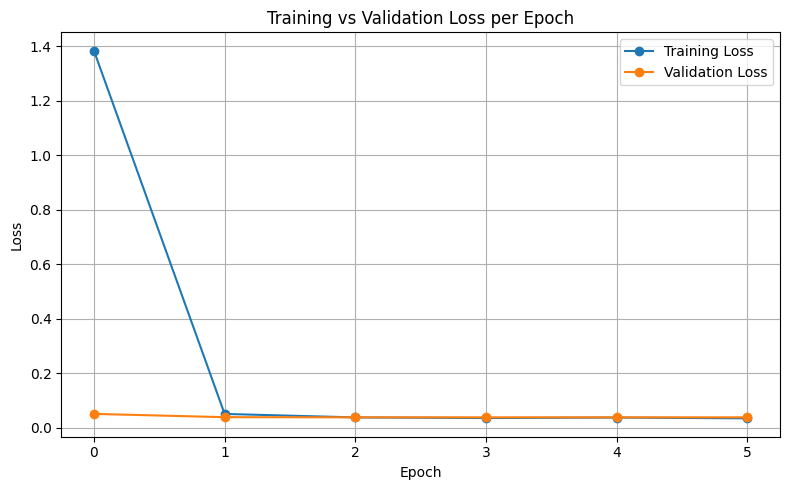

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("T5__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# epochs = 3
# for epoch in tqdm(range(epochs)):
#     model.train()
#     total_loss = 0
#     for batch in train_dataloader:
#         b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
#         # resetting gradients before backpropagation
#         model.zero_grad()
#         # performing a forward pass to calculate outputs
#         outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
#         # calculating the loss 
#         loss = outputs.loss
#         total_loss += loss.item()
#         # backpropagating the loss to compute gradients
#         loss.backward()
#         # updating model parameters using the computed gradients
#         optimizer.step()
#     avg_train_loss = total_loss / len(train_dataloader)
#     print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

## Making predictions

In [28]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 550
    })
})

In [29]:
# Convert the tokenized test dataset to pandas
df_test = tokenized_dataset['test'].to_pandas()

# Extract tokenized inputs and labels
X_test_inputs = np.array(df_test['input_ids'].tolist())
X_test_attention = np.array(df_test['attention_mask'].tolist())
y_test = np.array(df_test['labels'].tolist())  # ✅ these are already tokenized label IDs

# Convert to PyTorch tensors
test_inputs = torch.tensor(X_test_inputs, dtype=torch.long)
test_attention = torch.tensor(X_test_attention, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [30]:
def get_predictions(model, dataloader, tokenizer, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            # Generate predictions using greedy decoding
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=10
            )

            # Decode generated tokens to strings
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

            predictions.extend(decoded_preds)
            true_labels.extend(decoded_labels)

    return predictions, true_labels


baseline_predictions, true_labels = get_predictions(model, test_dataloader, tokenizer, device)

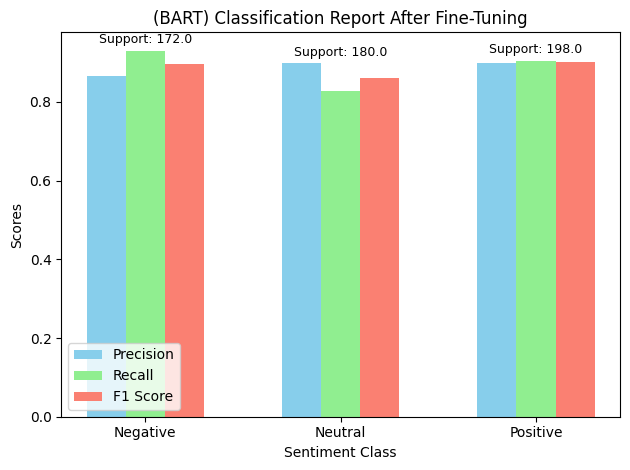

In [31]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('(BART) Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [32]:
print(report['accuracy'])

0.8872727272727273


In [36]:
import os
import pandas as pd

filepath = "/kaggle/working/tsa_model_expt_results.csv"

# Model results as a dict
df_model = {
    "Name": "T5",
    "Training Loss": opt_train_loss,
    "Validation Loss": best_val_loss,
    "Accuracy": report['accuracy']
}

# Convert to DataFrame
df_model = pd.DataFrame([df_model])  # Note the brackets to make it a list of dicts

# If file exists, append to it
if os.path.exists(filepath):
    results = pd.read_csv(filepath)
    results = pd.concat([results, df_model], ignore_index=True)
else:
    results = df_model  # Start a new DataFrame

# Save the updated DataFrame back to CSV
# print(results)
results.to_csv(filepath, index=False)

In [39]:
results = results.drop(columns=['Unnamed: 0'])

In [40]:
# df_models = pd.DataFrame(df_models)
results.to_csv("tsa_model_expt_results.csv", index=False)

In [41]:
results

,Name,Training Loss,Validation Loss,Accuracy
0,BART,0.148998,0.193558,0.909091
1,RoBERTa,0.081400,0.406700,0.941800
2,T5,0.038137,0.038477,0.887273
